# Visualizing topics

In [1]:
# load 2D UMAP embeddings from a file

import joblib
docs_umap_embeddings = joblib.load('data/umap_embeddings_robbert.pkl')

docs_umap_embeddings.shape

(41119, 2)

In [24]:
# import labels from the document file
import pandas as pd
docs_df = pd.read_csv('results/models/robbert_reduced/doc_info_reduced_outliers.csv')
# sort the df by "Count" and reset the index

# get the rows "Document" and "Topic" from this dataframe
docs = docs_df[['Document', 'Topic']]
# import the topic information
topic_info = pd.read_csv('results/models/robbert_reduced/topic_info_reduced_outliers.csv')
# sort topic info by count and reset index
topic_info = topic_info.sort_values(by='Count', ascending=False).reset_index(drop=True)
# get the rows "topic_num" and "translation" from this dataframe
topic_info["Rank"] = topic_info.index + 1
topic_labels = topic_info[['Topic', 'Translation', "Label", "Rank"]]
topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs,Label,Translation,Rank
0,0,1450,0_ontlasting_ingeleverd_inleveren_bloed,"['ontlasting', 'ingeleverd', 'inleveren', 'blo...",NaN,Handing in blood/stool samples,"Topic 0: stool, handed in, hand in, blood",1
1,2,1332,2_apotheek_recept_locatie_sturen,"['apotheek', 'recept', 'locatie', 'sturen', 'n...",NaN,Pharmacy and prescription,"Topic 2: pharmacy, prescription, location, send",2
2,1,1310,1_bellen_bereikbaar_telefonisch_gebeld,"['bellen', 'bereikbaar', 'telefonisch', 'gebel...",NaN,Phone calls,"Topic 1: call, reachable, by phone, called",3
3,3,974,3_mail_ontvangen_gestuurd_bericht,"['mail', 'ontvangen', 'gestuurd', 'bericht', '...",NaN,Mails and messages,"Topic 3: mail, received, sent, message",4
4,4,899,4_afspraak_staan_verzetten_gepland,"['afspraak', 'staan', 'verzetten', 'gepland', ...",NaN,Appointments,"Topic 4: appointment, scheduled, reschedule, p...",5


In [22]:
# calculate the frequency of the first 10 topics with n_total = 41119
for i in range(1, 11):
    n_topic = topic_info.loc[topic_info['Rank'] == i, 'Count'].values[0]
    label = topic_info.loc[topic_info['Rank'] == i, 'Label'].values[0]
    n_total = len(docs)
    freq = n_topic / 41119 * 100
    print(f'Topic {i}, {label}: {n_topic} documents, frequency: {freq:.1f} %')

Topic 1, Handing in blood/stool samples: 1450 documents, frequency: 3.5 %
Topic 2, Pharmacy and prescription: 1332 documents, frequency: 3.2 %
Topic 3, Phone calls: 1310 documents, frequency: 3.2 %
Topic 4, Mails and messages: 974 documents, frequency: 2.4 %
Topic 5, Appointments: 899 documents, frequency: 2.2 %
Topic 6, Contact with GPs and doctors: 861 documents, frequency: 2.1 %
Topic 7, Medication use/discontinuation: 710 documents, frequency: 1.7 %
Topic 8, Blood drawing: 671 documents, frequency: 1.6 %
Topic 9, Humira injection: 602 documents, frequency: 1.5 %
Topic 10, Date and schedule: 540 documents, frequency: 1.3 %


In [26]:
# Map the "translation" of each document based on its "Topic"
doc_labels = docs.merge(topic_labels, left_on='Topic', right_on='Topic', how='left')
doc_labels.head()

,Document,Topic,Translation,Label,Rank
0,"Geachte ibd groep, Is mijn uitslag al binnen ...",9,"Topic 9: result, results, of this, known",Results inquiry,13
1,Vorige week is door [ZIEKENHUIS] [LOCATIE] mij...,0,"Topic 0: stool, handed in, hand in, blood",Handing in blood/stool samples,1
2,Graag zou ik de uitkomst hiervan vernemen.,9,"Topic 9: result, results, of this, known",Results inquiry,13
3,bloed in de ontlasting wordt steeds meer en st...,48,"Topic 48: blood, stool, clear, present\r",Blood in stool,53
4,Ligt dit aan de medicatie?,154,NaN,NaN,106


In [27]:
# make a new column "plot_labels" in doc_labels where only selected Topic numbers are shown with their translation, and the rest are labeled as "Unlabbelled" 
selected_topics = range(0, 30)
def label_topic(row):
    if row['Topic'] in selected_topics and not pd.isna(row['Label']):
        return f"{row['Rank']}: {row['Label']}"
    else:
        return "Unlabelled"
doc_labels['plot_labels'] = doc_labels.apply(label_topic, axis=1)
plot_labels = doc_labels['plot_labels'].tolist()
plot_labels[:10]

['13: Results inquiry',
 '1: Handing in blood/stool samples',
 '13: Results inquiry',
 'Unlabelled',
 'Unlabelled',
 '21: Prednoisone and tapering',
 '21: Prednoisone and tapering',
 '7: Medication use/discontinuation',
 'Unlabelled',
 '45: Purinethol use']

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


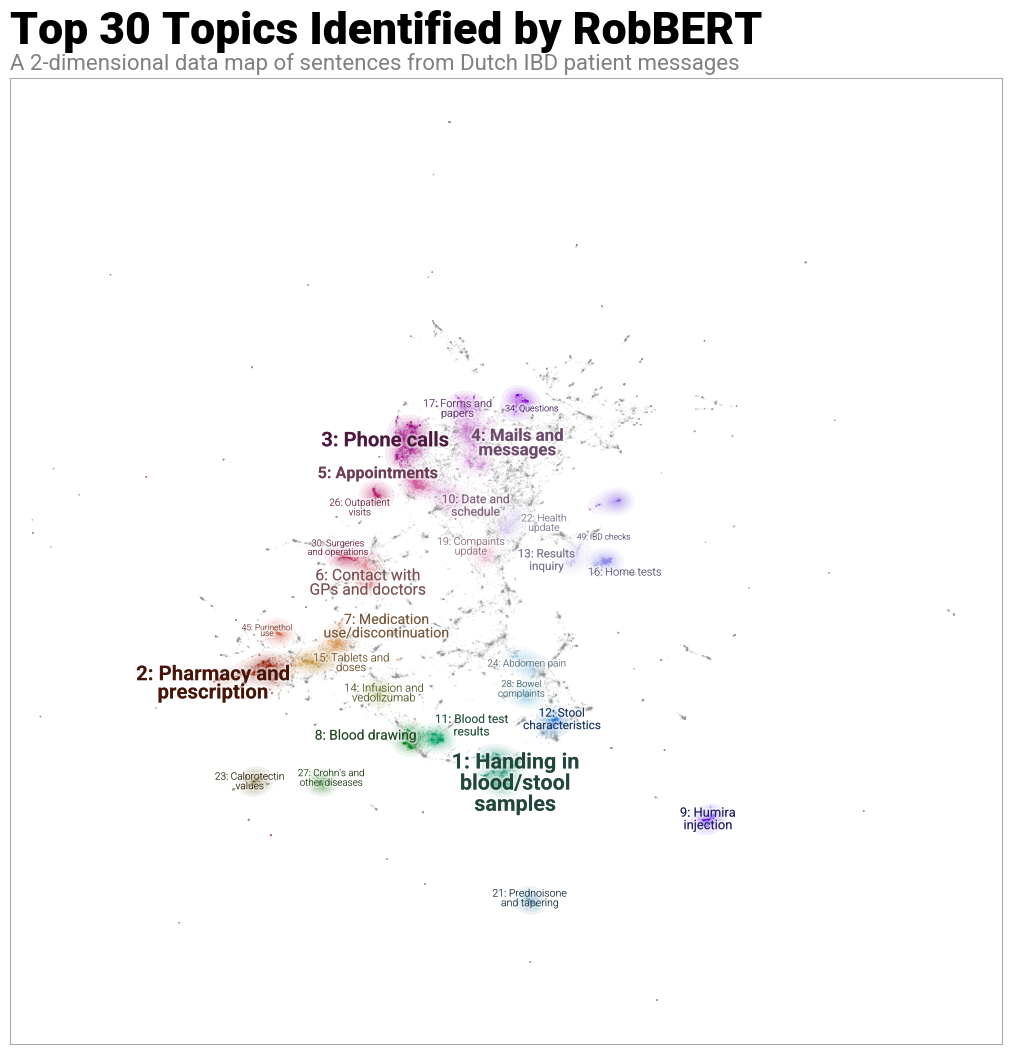

In [28]:
# import datamapplot
import datamapplot as dmp
# Ensure we don't generate large images for inline docs
# You probably want to remove this if running the notebook yourself
import matplotlib as plt
fig = dmp.create_plot(
    docs_umap_embeddings, 
    plot_labels,
    title="Top 30 Topics Identified by RobBERT",
    sub_title="A 2-dimensional data map of sentences from Dutch IBD patient messages",
    label_over_points=True,
    dynamic_label_size=True,
    max_font_size=40,
    min_font_size=6,
)

# Save the figure at higher DPI
fig[0].savefig("robbbert_30topics_map.png", dpi=600, bbox_inches="tight")